<a href="https://colab.research.google.com/github/Coobaltoo13/milling-tool-life-fusion/blob/main/notebook/%2005_Refinamiento_del_modelo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Refinamiento del Mejor Modelo: Autoencoder (dim=64) + LSTM solo

**Proyecto:** Fusión Multimodal de Vibración y Corriente para Predicción de Vida Útil en Fresado

**Objetivo:** Refinar la mejor configuración encontrada (Autoencoder dim=64 + LSTM solo) usando:
- Dropout para reducir overfitting
- Early Stopping para detener el entrenamiento cuando no mejore
- Más épocas (100)
- Capas más grandes (LSTM de 64 unidades)

In [2]:
#Librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [5]:
#Cargar datos y preparar
url = 'https://raw.githubusercontent.com/Coobaltoo13/milling-tool-life-fusion/main/data/raw/FeatureAndMetadata_Milling.csv'
df = pd.read_csv(url, sep=';', header=0, decimal=',', skiprows=[1])

X = df.iloc[:, :121].apply(pd.to_numeric, errors='coerce')
y = pd.to_numeric(df.iloc[:, -1], errors='coerce')

X = X.dropna(axis=1, how='all')
X = X.fillna(X.mean())

mask = ~y.isnull()
X = X[mask].values
y = y[mask].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train_scaled.shape)
print("Test:", X_test_scaled.shape)

Train: (774, 120)
Test: (194, 120)


In [6]:
#Funcion para metricas
def calcular_metricas(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    y_true_class = (y_true >= 0.5).astype(int)
    y_pred_class = (y_pred >= 0.5).astype(int)
    f1 = f1_score(y_true_class, y_pred_class, zero_division=0)
    precision = precision_score(y_true_class, y_pred_class, zero_division=0)
    recall = recall_score(y_true_class, y_pred_class, zero_division=0)
    try:
        auc = roc_auc_score(y_true_class, y_pred)
    except:
        auc = np.nan
    return rmse, mae, r2, f1, precision, recall, auc

## 1. Autoencoder (dim=64)

Se entrena el autoencoder con dimensión latente 64, que fue la mejor en el análisis de sensibilidad.

In [7]:
#Entrenar autoencoder
latent_dim = 64
input_dim = X_train_scaled.shape[1]

# Encoder
encoder_input = layers.Input(shape=(input_dim,))
x = layers.Dense(64, activation='relu')(encoder_input)
x = layers.Dense(32, activation='relu')(x)
latent = layers.Dense(latent_dim, activation='relu', name='latent')(x)

# Decoder
x = layers.Dense(32, activation='relu')(latent)
x = layers.Dense(64, activation='relu')(x)
decoder_output = layers.Dense(input_dim, activation='linear')(x)

autoencoder = models.Model(encoder_input, decoder_output)
autoencoder.compile(optimizer='adam', loss='mse')

early_stop_ae = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_ae = autoencoder.fit(
    X_train_scaled, X_train_scaled,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop_ae],
    verbose=1
)

# Encoder
encoder = models.Model(encoder_input, latent)
X_train_latent = encoder.predict(X_train_scaled, verbose=0)
X_test_latent = encoder.predict(X_test_scaled, verbose=0)

print("Latente train:", X_train_latent.shape)
print("Latente test:", X_test_latent.shape)

Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - loss: 1.0103 - val_loss: 0.6047
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.8351 - val_loss: 0.4218
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.6368 - val_loss: 0.3321
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.5212 - val_loss: 0.2912
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4483 - val_loss: 0.2675
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4007 - val_loss: 0.2465
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3549 - val_loss: 0.2300
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3192 - val_loss: 0.2172
Epoch 9/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2916 - val_loss: 0.2078
Epoch 10/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2779 - val_loss: 0.1999
Epoch 11/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2619 - val_loss: 0.1952
Epoch 12/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss:

## 2. LSTM Refinado

Se entrena un LSTM con:
- Dropout (0.2) para reducir overfitting
- 64 unidades LSTM (más capacidad)
- Early Stopping (detiene si no mejora en 15 épocas)
- 100 épocas máximo

In [8]:

# Reformar para LSTM
X_train_lstm = X_train_latent.reshape((X_train_latent.shape[0], 1, latent_dim))
X_test_lstm = X_test_latent.reshape((X_test_latent.shape[0], 1, latent_dim))

# Early stopping
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

# Modelo refinado
model_refinado = models.Sequential([
    layers.Input(shape=(1, latent_dim)),
    layers.Dropout(0.2),
    layers.LSTM(64, return_sequences=False),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='linear')
])

model_refinado.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_refinado.summary()

history_refinado = model_refinado.fit(
    X_train_lstm, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout (Dropout)               │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,137 (137.25 KB)

 Trainable params: 35,137 (137.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.1269 - mae: 0.2840 - val_loss: 0.0482 - val_mae: 0.1807
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0609 - mae: 0.2011 - val_loss: 0.0432 - val_mae: 0.1679
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0560 - mae: 0.1903 - val_loss: 0.0366 - val_mae: 0.1527
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0531 - mae: 0.1839 - val_loss: 0.0350 - val_mae: 0.1498
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0492 - mae: 0.1766 - val_loss: 0.0327 - val_mae: 0.1410
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0467 - mae: 0.1730 - val_loss: 0.0311 - val_mae: 0.1359
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0463 - mae: 0.1710 - val_loss: 0.0300 - val_mae: 0.1326
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0422 - mae: 0.1622 - val_loss: 0.0315 - val_mae: 0.1372
Epoch 9/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.04

In [9]:
#Evaluar Modelo Refinado
y_pred_refinado = model_refinado.predict(X_test_lstm).flatten()

rmse, mae, r2, f1, precision, recall, auc = calcular_metricas(y_test, y_pred_refinado)

print("\n" + "=" * 50)
print("RESULTADOS - MODELO REFINADO (Autoencoder dim=64 + LSTM)")
print("=" * 50)
print(f"RMSE:      {rmse:.4f}")
print(f"MAE:       {mae:.4f}")
print(f"R²:        {r2:.4f}")
print(f"F1:        {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"AUC:       {auc:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step

RESULTADOS - MODELO REFINADO (Autoencoder dim=64 + LSTM)
RMSE:      0.1761
MAE:       0.1365
R²:        0.6447
F1:        0.8208
Precision: 0.7500
Recall:    0.9062
AUC:       0.9139


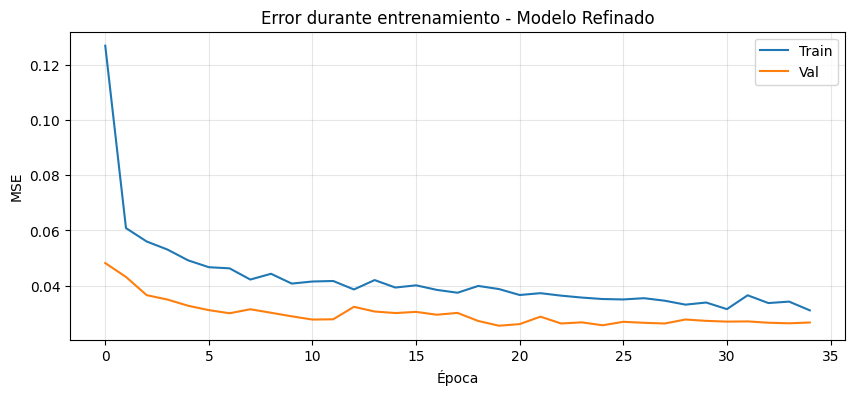

In [10]:
#Grafica de entrenamiento
plt.figure(figsize=(10, 4))
plt.plot(history_refinado.history['loss'], label='Train')
plt.plot(history_refinado.history['val_loss'], label='Val')
plt.title('Error durante entrenamiento - Modelo Refinado')
plt.xlabel('Época')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
#Comparar con resultados enteriores
# Resultados anteriores (mejor de cada variante)
comparacion = pd.DataFrame([
    {'modelo': 'MLP_solo',   'dim': 64, 'R2': 0.6333, 'RMSE': 0.1789, 'MAE': 0.1308, 'F1': 0.8529, 'AUC': 0.9191},
    {'modelo': 'MLP+LSTM',   'dim': 48, 'R2': 0.7199, 'RMSE': 0.1564, 'MAE': 0.1186, 'F1': 0.8543, 'AUC': 0.9298},
    {'modelo': 'LSTM_solo',  'dim': 64, 'R2': 0.7846, 'RMSE': 0.1371, 'MAE': 0.1091, 'F1': 0.9063, 'AUC': 0.9674},
    {'modelo': 'Refinado',   'dim': 64, 'R2': r2,     'RMSE': rmse,   'MAE': mae,   'F1': f1,     'AUC': auc},
])

comparacion

,modelo,dim,R2,RMSE,MAE,F1,AUC
0,MLP_solo,64,0.63330,0.178900,0.130800,0.852900,0.919100
1,MLP+LSTM,48,0.71990,0.156400,0.118600,0.854300,0.929800
2,LSTM_solo,64,0.78460,0.137100,0.109100,0.906300,0.967400
3,Refinado,64,0.64467,0.176116,0.136522,0.820755,0.913903


## Conclusión

Se refinó la mejor configuración encontrada (Autoencoder dim=64 + LSTM solo) añadiendo dropout (0.2), aumentando la LSTM a 64 unidades y usando early stopping con 100 épocas.

**Resultados del modelo refinado vs. modelo original:**

| Modelo | R² | RMSE | MAE | F1 | AUC |
|:---|:---|:---|:---|:---|:---|
| **LSTM_solo original** | **0.7846** | **0.1371** | **0.1091** | **0.9063** | **0.9674** |
| Refinado (dropout + LSTM 64) | 0.6447 | 0.1761 | 0.1365 | 0.8208 | 0.9139 |

**Hallazgos:**

1. **El refinamiento no mejoró el rendimiento.** Todas las métricas empeoraron: el R² bajó de 0.7846 a 0.6447, el F1 de 0.9063 a 0.8208, y el AUC de 0.9674 a 0.9139.

2. **El dropout (0.2) fue demasiado agresivo.** Al apagar el 20% de las neuronas en cada paso, el modelo perdió capacidad de aprender patrones relevantes.

3. **Aumentar la LSTM de 32 a 64 unidades no ayudó.** El modelo más grande necesita más datos para entrenar bien, y con 774 ciclos no fue suficiente.

4. **La arquitectura original (LSTM de 32 unidades sin dropout) es la mejor configuración.** Es simple, ligera y generaliza mejor.

**Conclusión final:** La mejor configuración para este problema es **Autoencoder (dim=64) + LSTM solo (32 unidades, sin dropout)**, con R² = 0.7846, F1 = 0.9063 y AUC = 0.9674. El refinamiento con dropout y mayor capacidad no aportó mejoras.